### Dataset Datos de segmentación de clientes de centros comerciales

## Instalar pandas

In [1]:
!pip install pandas

## Cargar dataset

In [3]:
import pandas as pd

df = pd.read_csv('Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## Paso 1: Análisis Exploratorio de Datos (EDA)


In [10]:
print(df.describe())


       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


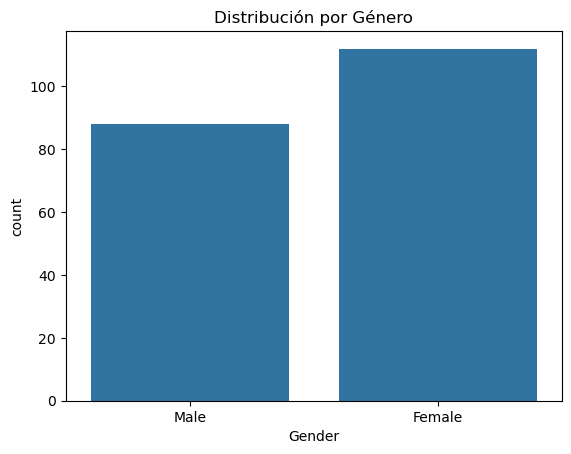

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Gender', data=df)
plt.title('Distribución por Género')
plt.show()

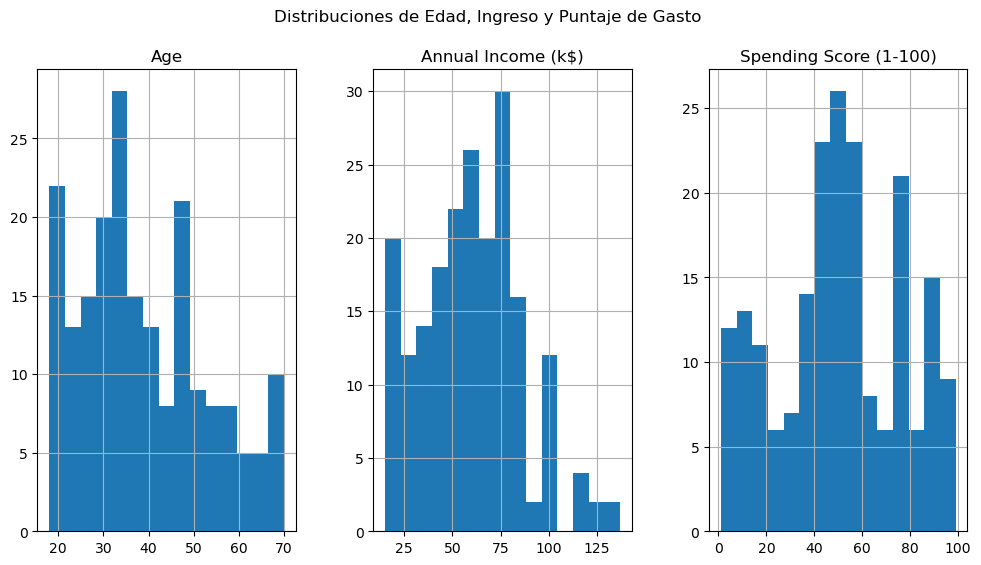

In [14]:
df.hist(column=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], bins=15, figsize=(12, 6), layout=(1, 3))
plt.suptitle('Distribuciones de Edad, Ingreso y Puntaje de Gasto')
plt.show()

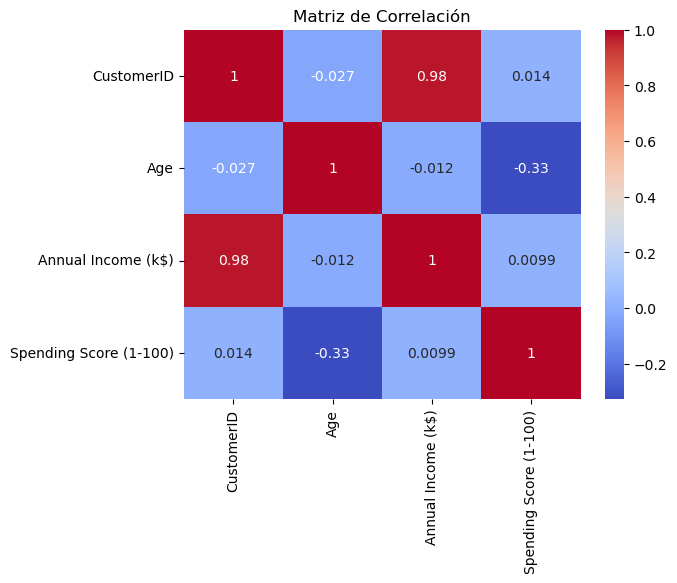

In [16]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

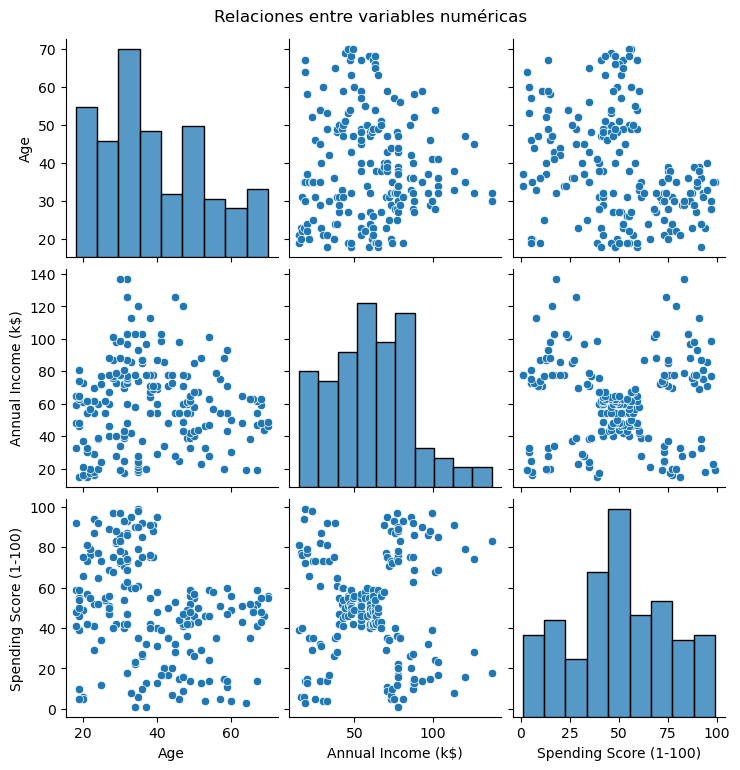

In [18]:
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
plt.suptitle('Relaciones entre variables numéricas', y=1.02)
plt.show()

## Paso 2: Preprocesamiento de los datos

In [21]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Eliminar columna CustomerID
df_clean = df.drop('CustomerID', axis=1)

# 2. Codificar variable 'Gender' (0 = Female, 1 = Male)
le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])

# 3. Verificar valores nulos
print(df_clean.isnull().sum())

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


## Paso 3 Seleccionar las características más relevantes para entrenar el modelo
1. Age, Annual Income (k$) y Spending Score (1-100) tienen baja correlación entre sí, lo cual es bueno para clustering, ya que pueden aportar información distinta.
2. Se observa una posible estructura de grupos entre:

- Annual Income y Spending Score (hay clústeres visuales definidos).

- Age y Spending Score también muestran cierta separación.

# Usaremos las siguientes variables para el clustering:

1. Age

2. Annual Income (k$)

3. Spending Score (1-100)

Excluimos:

1. CustomerID: Es un identificador, no aporta al modelo.

2. Gender: Es categórica y K-Means no la procesa directamente (a menos que se codifique, pero no es fundamental en este análisis).

## Paso 4: Entrenar modelo

In [27]:
from sklearn.preprocessing import StandardScaler

# Selección de características
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


C:\Users\mavan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mavan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mavan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mavan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

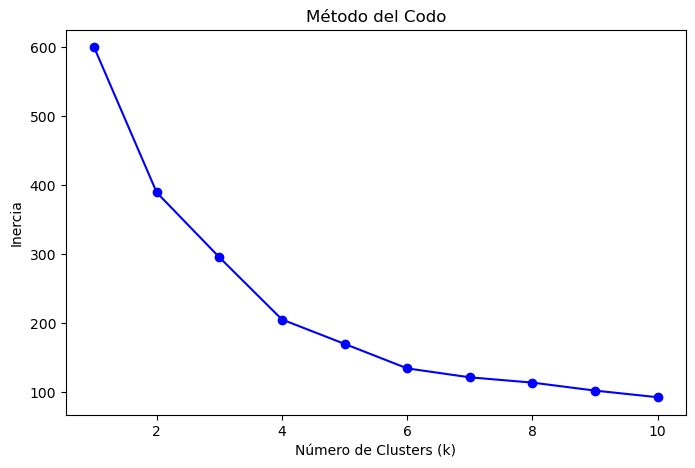

In [31]:
#Encontrar el npúmero de clusters apropiado
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Gráfico del codo
plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()


### Se observa una inflexión pronunciada en k = 5, donde la disminución de la inercia comienza a volverse más suave. Esto indica que 5 es un valor óptimo para el número de clusters

## Paso 5: Entrenar el modelo K-Means con k=5

In [36]:
# Entrenar modelo K-Means con k=5
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_scaled)

# Añadir etiquetas al DataFrame original
df['Cluster'] = kmeans.labels_


C:\Users\mavan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


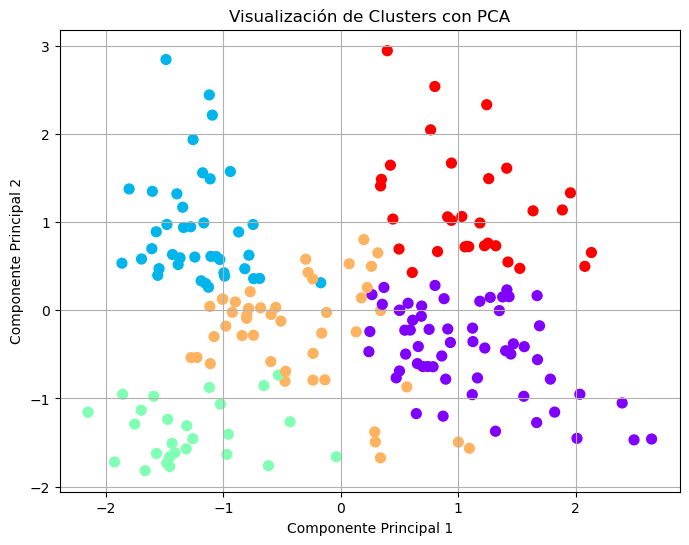

In [38]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reducir dimensiones con PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

# Crear gráfico de dispersión con los clusters
plt.figure(figsize=(8, 6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=kmeans.labels_, cmap='rainbow', s=50)
plt.title('Visualización de Clusters con PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()
